In [ ]:
import geopandas as gpd
import osmnx as ox
import swisslandstats as sls
import urban_footprinter as ufp

In [ ]:
nominatim_query = "Canton de Vaud"
lulc_col = "LU18_4"
ldf_buffer_dist = 10000
urban_lulc_class = 1

kernel_radius = 500
urban_threshold = 0.25
buffer_dist = 500

dst_filepath = "../data/processed/lausanne-extent.gpkg"

In [ ]:
gdf = (
    ox.geocode_to_gdf(nominatim_query)
    .to_crs(sls.settings.DEFAULT_CRS)
    .buffer(ldf_buffer_dist)
)

In [ ]:
ldf = sls.load_dataset(dataset_key="sls").clip_by_geometry(
    gdf.iloc[0], geometry_crs=gdf.crs
)

<Axes: >

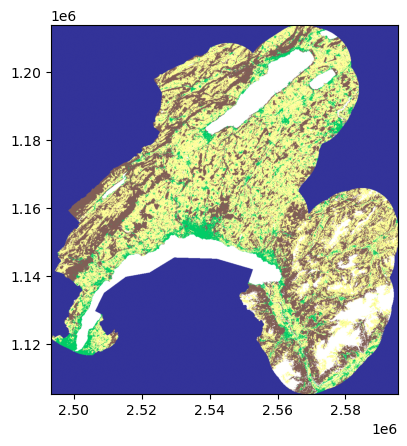

In [ ]:
ldf.plot(lulc_col)

In [ ]:
lulc_arr = ldf.to_ndarray(lulc_col)

In [ ]:
geom = ufp.urban_footprint_mask_shp(
    lulc_arr,
    kernel_radius,
    urban_threshold,
    urban_classes=urban_lulc_class,
    buffer_dist=buffer_dist,
    res=ldf.res[0],
    transform=ldf.get_transform(),
)

In [ ]:
gpd.GeoSeries(geom, crs=ldf.crs).explode().to_file(dst_filepath)